In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# data
# ---motion bias outside capsule---
# [WT_5um_outside_capsule]
# "D:\Rui_Zeng_Data\Nikon_Minaj_bigdata\20241130_RZ_AF555_546_entry_escape_bias_1st\bias\20241130_181142_570_video0\open_forward_backward_count_20241130_181142_570_video0.xlsx"
# F120 B62 (done)


# ---motion bias inside capsule---
# "C:\Folder_for_Analysis\Rui_Zeng\2024_bug_in_capsule\figure_4\mode_duration_in_small+large\process+plot.ipynb"
# 0.35+-0.16 for large (N=108)
# 0.26+-0.11 for small (N=57)

# ---entry/escape count---
# "C:\Folder_for_Analysis\Rui_Zeng\2024_bug_in_capsule\figure_3\Fig.3_v4.1.png"
# entry: F60 B70
# escape: FI 21, FII 20, B 88
# escape: FI 32, FII 25, B 89

In [3]:
# ---motion bias outside capsule---
# F120 B62 (done)
# ---entry count---
# entry: F60 B70


0.34065934065934067 0.35


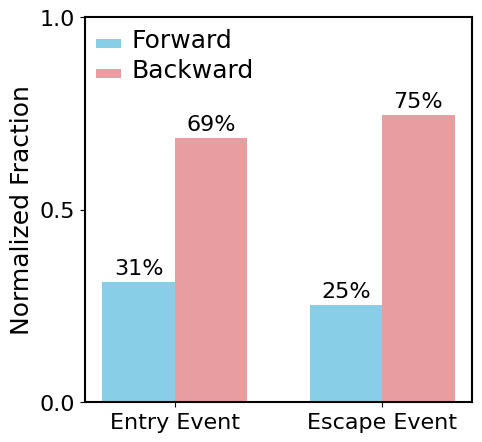

In [4]:
# Data
motion_forward = 120
motion_backward = 62
motion_total = motion_forward + motion_backward
backward_fraction_outside = motion_backward/motion_total

entry_forward = 60
entry_backward = 70
entry_total = entry_forward + entry_backward

backward_fraction_inside = 0.35
escape_forward = 32 + 25
escape_backward = 89
escape_total = escape_forward + escape_backward

# Frequencies normlized by motion bias
entry_freq = [entry_forward / entry_total/(1-backward_fraction_outside), entry_backward / entry_total/(backward_fraction_inside)]
escape_freq = [escape_forward / escape_total/(1-backward_fraction_outside), escape_backward / escape_total/(backward_fraction_inside)]
# norm to sum = 1
entry_freq = entry_freq / np.sum(entry_freq)
escape_freq = escape_freq / np.sum(escape_freq)



# Colors
color_red = '#E89DA0'  # backward
color_blue = '#88CEE6'  # forward

# Positions
bar_width = 0.35
x = np.array([0, 1])  # 0 = motion, 1 = entry

# Plot
plt.figure(figsize=(5, 5))

# Forward bars
plt.bar(x - bar_width/2, [entry_freq[0], escape_freq[0]], width=bar_width, label='Forward', color=color_blue)
# Backward bars
plt.bar(x + bar_width/2, [entry_freq[1], escape_freq[1]], width=bar_width, label='Backward', color=color_red)

# X-axis
plt.xticks(x, ['Entry Event', 'Escape Event'], fontsize=18)
plt.ylabel('Normalized Fraction', fontsize=18)
plt.ylim(0, 1.0)
\

# Annotate values
plt.text(x[0] - bar_width/2, entry_freq[0] + 0.02, f'{entry_freq[0]*100:.0f}%', ha='center', fontsize=8)
plt.text(x[0] + bar_width/2, entry_freq[1] + 0.02, f'{entry_freq[1]*100:.0f}%', ha='center', fontsize=8)
plt.text(x[1] - bar_width/2, escape_freq[0] + 0.02, f'{escape_freq[0]*100:.0f}%', ha='center', fontsize=8)
plt.text(x[1] + bar_width/2, escape_freq[1] + 0.02, f'{escape_freq[1]*100:.0f}%', ha='center', fontsize=8)

# Style
plt.legend(frameon=False, fontsize=9, loc='upper left')

# plt.figure(figsize=(6,5.5))

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=16)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=18)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=18)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(18)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(16)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
# ax.locator_params(axis='y', nbins=6)
# ax.locator_params(axis='x', nbins=6)
# set yticks
ax.set_yticks([0, 0.5, 1])

## Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('normalized_entry_escape_fraction.png', format='png', dpi=900, transparent=True, bbox_inches='tight')

# print backward_fraction_outside, backward_fraction_inside
print(backward_fraction_outside, backward_fraction_inside)
